In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc

from src.config import PROCESSED_DIR, REPORTS_DIR

df = pd.read_parquet(PROCESSED_DIR / "assist_test_with_struggle.parquet")
print("Shape:", df.shape)
df[["user_id", "skill_id", "y_repair_need", "repair_need_score",
    "y_effort_cost", "effort_cost_score",
    "y_disengagement", "disengagement_risk"]].head()

Shape: (81148, 27)


,user_id,skill_id,y_repair_need,repair_need_score,y_effort_cost,effort_cost_score,y_disengagement,disengagement_risk
0,21825,12,0,0.122342,1.0,1.402514,0.116027,0.111460
1,21825,10,0,0.026694,1.0,0.913075,0.771685,0.770280
2,21825,12,0,0.048486,1.0,1.255163,0.771685,0.767860
3,21825,10,0,0.045604,1.0,1.157805,0.472487,0.475062
4,21825,12,0,0.045128,1.0,1.220605,0.472487,0.473998


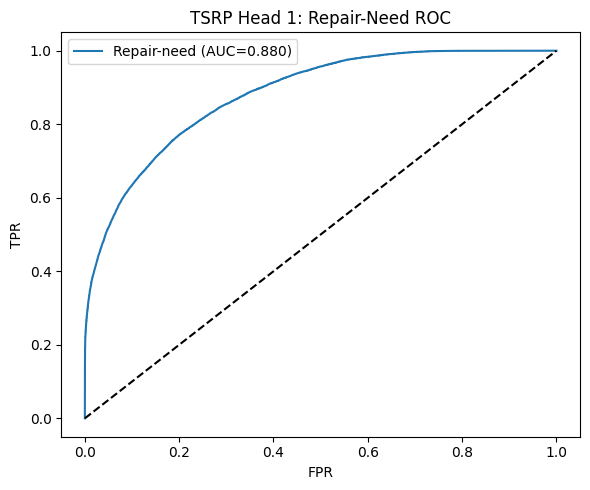

In [6]:
fpr, tpr, _ = roc_curve(df["y_repair_need"], df["repair_need_score"])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Repair-need (AUC={sk_auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("TSRP Head 1: Repair-Need ROC")
plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_DIR / "tsrp_repair_roc.png", dpi=120)
plt.show()

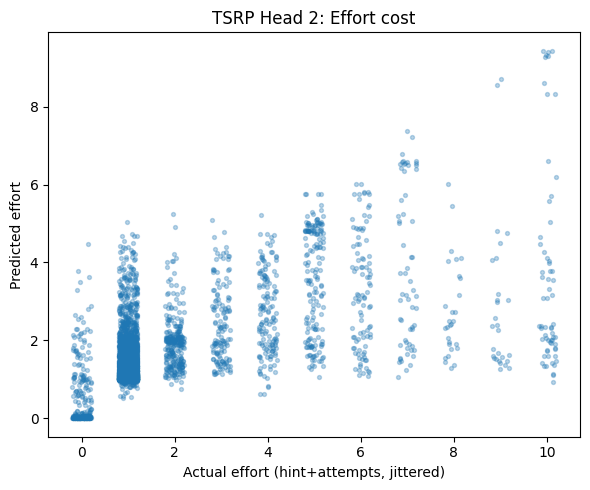

In [7]:
import numpy as np
plt.figure(figsize=(6, 5))
sample = df.sample(min(5000, len(df)), random_state=42)
plt.scatter(sample["y_effort_cost"] + np.random.uniform(-0.2, 0.2, len(sample)),
            sample["effort_cost_score"], alpha=0.3, s=8)
plt.xlabel("Actual effort (hint+attempts, jittered)")
plt.ylabel("Predicted effort")
plt.title("TSRP Head 2: Effort cost")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "tsrp_effort_scatter.png", dpi=120)
plt.show()

In [8]:
from src.models.struggle_predictor import StrugglePredictor
tsrp = StrugglePredictor()
row = df.iloc[100]
feat = {c: row[c] for c in tsrp.feature_cols}
v = tsrp.predict(feat)
print("Sample row:")
print(f"  user_id={row['user_id']}, skill_id={row['skill_id']}")
print(f"  Actual: repair_need={row['y_repair_need']}, effort={row['y_effort_cost']:.1f}")
print(f"  Predicted struggle vector: {v}")

Sample row:
  user_id=70684, skill_id=280
  Actual: repair_need=1, effort=2.0
  Predicted struggle vector: {'repair_need_score': 0.05868263005002008, 'effort_cost_score': 1.1566543690532836, 'disengagement_risk': 1.029314150624143}
